In [1]:
# -- Set Project root
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

%reload_ext autoreload
%autoreload 2

/teamspace/studios/this_studio/Airport-AI


In [2]:
# -- Load configuration
from airport_ai.config import config

print("Config loaded")

print(
    config.get("cameras")
)

print(
    config.get("database")
)

Loading configuration: /teamspace/studios/this_studio/Airport-AI/airport_ai/config/config.yaml
Project root: /teamspace/studios/this_studio/Airport-AI
Config loaded
[{'camera_id': 'GATE_A01', 'camera_name': 'Gate A01', 'source': 'data/videos/04_sample.mp4'}, {'camera_id': 'GATE_B03', 'camera_name': 'Gate B03', 'source': 'data/videos/02_sample.mp4'}, {'camera_id': 'GATE_C04', 'camera_name': 'Gate C04', 'source': 'data/videos/03_sample.mp4'}]
{'path': 'data/database/airport_monitor.db'}


In [ ]:
# -- Verify resolved paths
video_path = config.resolve_path(
    config.get("cameras")[0]["source"]
)

database_path = config.resolve_path(
    config.get("database")["path"]
)


print("VIDEO")
print(video_path)

print("\nDATABASE")
print(database_path)

VIDEO
/teamspace/studios/this_studio/Airport-AI/data/videos/04_sample.mp4

DATABASE
/teamspace/studios/this_studio/Airport-AI/data/database/airport_monitor.db


In [ ]:
# -- Test video source
from airport_ai.streams.video_source import VideoSource

source = VideoSource(video_path)

ok, frame = source.read()

source.release()

print("Read:", ok)

if frame is not None:
    print(frame.shape)

Opening Video: /teamspace/studios/this_studio/Airport-AI/data/videos/04_sample.mp4
Read: True
(480, 854, 3)


In [5]:
# -- Build complete application
from airport_ai.app.builder import ApplicationBuilder


builder = ApplicationBuilder(
    config
)


application = builder.build()


print(
    "Pipelines:",
    len(application.pipelines)
)

Database: /teamspace/studios/this_studio/Airport-AI/data/database/airport_monitor.db


Opening Video: /teamspace/studios/this_studio/Airport-AI/data/videos/04_sample.mp4
Opening Video: /teamspace/studios/this_studio/Airport-AI/data/videos/02_sample.mp4
Opening Video: /teamspace/studios/this_studio/Airport-AI/data/videos/03_sample.mp4
Pipelines: 3


In [6]:
# -- Verify services
pipeline = application.pipelines[0]

print("Camera:")
print(
    pipeline.camera_id
)

print("\nInference:")
print(
    type(pipeline.inference_engine)
)

print("\nTracker:")
print(
    type(pipeline.tracker)
)

print("\nVisualizer:")
print(
    type(pipeline.visualizer)
)

print("\nStorage:")
print(
    type(pipeline.storage_writer)
)

Camera:
GATE_A01

Inference:
<class 'airport_ai.inference.yolo_engine.YOLOEngine'>

Tracker:
<class 'airport_ai.tracking.tracker.ObjectTracker'>

Visualizer:
<class 'airport_ai.visualization.visualizer.Visualizer'>

Storage:
<class 'airport_ai.storage.writer.StorageWriter'>


In [ ]:
# -- Verify AsyncCamera
camera = pipeline.camera


print(
    "Camera object:",
    type(camera)
)


print(
    "FrameBuffer object:",
    type(camera.buffer)
)

print(
    "Running:",
    camera.running
)


print(
    "Buffer size:",
    camera.buffer.size()
)

Camera object: <class 'airport_ai.streams.camera.AsyncCamera'>
FrameBuffer object: <class 'airport_ai.streams.buffer.FrameBuffer'>
Running: True
Buffer size: 30


In [8]:
# Verify if the thread died because of EOF
camera = pipeline.camera

print("Running:", camera.running)

print(
    "Thread alive:",
    camera.thread.is_alive()
)

Running: True
Thread alive: True


In [9]:
# Check if the video ended
import cv2
print(
    camera.source.cap.isOpened()
)

print(
    camera.source.cap.get(cv2.CAP_PROP_POS_FRAMES)
)

print(
    camera.source.cap.get(cv2.CAP_PROP_FRAME_COUNT)
)

True
67.0
1803.0


In [10]:
import time

time.sleep(2)


print(
    camera.buffer.size()
)

30


In [11]:
# -- Read one pipeline frame
output = pipeline.process_frame()


print(
    type(output)
)


if output is not None:
    print(
        output.shape
    )

[HIGH] GATE_A01 TURNAROUND: Equipment 2 entered aircraft safety zone.

===== RUUNTIME METRICS =====
{'camera_id': 'GATE_A01', 'fps': 0, 'latency_ms': 1838.62, 'queue_size': 0, 'frames_processed': 1, 'status': 'STOPPED'}
<class 'numpy.ndarray'>
(720, 1280, 3)


In [12]:
# -- Verify YOLO output
frame = pipeline.camera.read()

detections = pipeline.inference_engine.detect(
    frame
)


print(
    "Detections:",
    len(detections)
)


if detections:
    print(
        type(detections[0])
    )

Detections: 4
<class 'airport_ai.inference.detection.Detection'>


In [ ]:
# Verify Tracker conversion
tracks = pipeline.tracker.update(
    detections
)


print(
    "Tracks:",
    len(tracks)
)


if tracks:
    print(
        type(tracks[0])
    )

Tracks: 4
<class 'airport_ai.inference.tracked_object.TrackedObject'>


In [ ]:
# Verify analytics
(
    safety_events,
    ppe_events,
    fod_events
) = pipeline.analytics_executor.evaluate(
    tracks,
    pipeline.turnaround,
    pipeline.ppe,
    pipeline.fod
)


print(
    "Safety:",
    len(safety_events)
)

print(
    "PPE:",
    len(ppe_events)
)

print(
    "FOD:",
    len(fod_events)
)

Safety: 2
PPE: 0
FOD: 0


In [15]:
# Verify Storage writer
for event in safety_events:

    pipeline.storage_writer.submit(
        pipeline.camera_id,
        "TURNAROUND",
        event
    )


print(
    "Queue:",
    pipeline.storage_writer.queue.qsize()
)

Queue: 2


In [16]:
# Confirm writer thread
print(
    pipeline.storage_writer.thread.is_alive()
)

True


In [17]:
# Allow databse flush
import time

time.sleep(3)

In [ ]:
# Verify SQLite persistence
repository = pipeline.repository


events = repository.get_recent(
    limit=10
)


print(
    "Stored events:",
    len(events)
)


for e in events:
    print(e)

Stored events: 10
('GATE_A01', '2026-07-29T18:56:04.372235', 'TURNAROUND', 7, '4', 'SAFETY_ZONE_INTRUSION', 'HIGH', 'Equipment 7 entered aircraft safety zone.')
('GATE_A01', '2026-07-29T18:56:04.372213', 'TURNAROUND', 6, '7', 'SAFETY_ZONE_INTRUSION', 'HIGH', 'Equipment 6 entered aircraft safety zone.')
('GATE_A01', '2026-07-29T18:56:02.915977', 'TURNAROUND', 2, '7', 'SAFETY_ZONE_INTRUSION', 'HIGH', 'Equipment 2 entered aircraft safety zone.')
('GATE_A01', '2026-07-29T18:40:42.276853', 'TURNAROUND', 166, '7', 'SAFETY_ZONE_INTRUSION', 'HIGH', 'Equipment 166 entered aircraft safety zone.')
('GATE_A01', '2026-07-29T18:40:42.276843', 'TURNAROUND', 165, '4', 'SAFETY_ZONE_INTRUSION', 'HIGH', 'Equipment 165 entered aircraft safety zone.')
('GATE_A01', '2026-07-29T18:40:42.276833', 'TURNAROUND', 164, '7', 'SAFETY_ZONE_INTRUSION', 'HIGH', 'Equipment 164 entered aircraft safety zone.')
('GATE_A01', '2026-07-29T18:40:42.276814', 'TURNAROUND', 163, '0', 'SAFETY_ZONE_INTRUSION', 'HIGH', 'Equipment 1

[HIGH] GATE_A01 TURNAROUND: Equipment 10 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 11 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 13 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 14 entered aircraft safety zone.

===== RUUNTIME METRICS =====
{'camera_id': 'GATE_A01', 'fps': 0.3, 'latency_ms': 1515.47, 'queue_size': 0, 'frames_processed': 2, 'status': 'WARNING'}


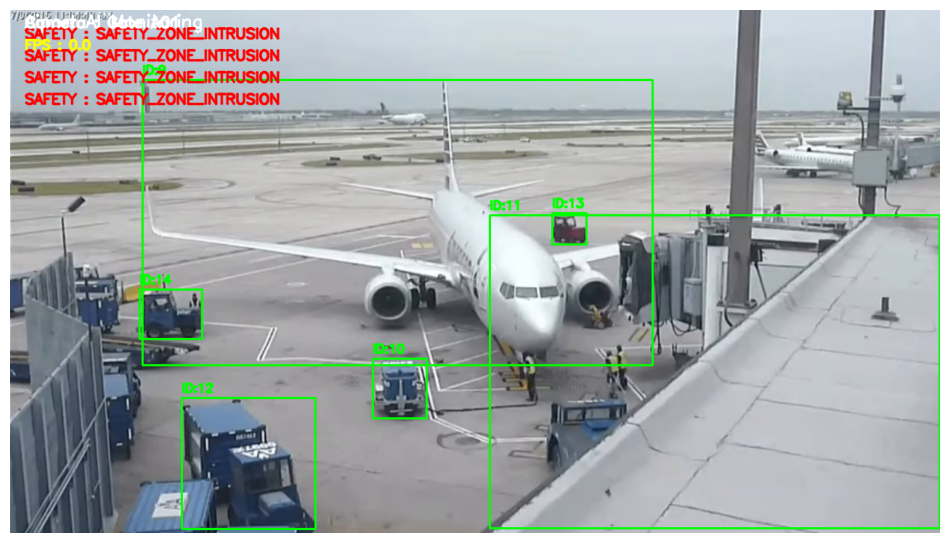

In [19]:
# -- Verify Visualization
import matplotlib.pyplot as plt

frame = None

while frame is None:
    frame = pipeline.process_frame()

plt.figure(figsize=(12,7))

plt.imshow(
    frame[:,:,::-1]
)

plt.axis("off")
plt.show()

In [ ]:
# -- Testing Demo
frame = pipeline.process_frame()

print("Output:", frame)
print("Type:", type(frame))

[HIGH] GATE_A01 TURNAROUND: Equipment 16 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 17 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 18 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 19 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 20 entered aircraft safety zone.

===== RUUNTIME METRICS =====
{'camera_id': 'GATE_A01', 'fps': 0.33, 'latency_ms': 1467.51, 'queue_size': 0, 'frames_processed': 3, 'status': 'WARNING'}
Output: [[[225 222 212]
  [211 208 198]
  [199 196 186]
  ...
  [230 219 207]
  [230 219 207]
  [230 219 207]]

 [[230 227 217]
  [217 214 204]
  [204 201 191]
  ...
  [230 219 207]
  [230 219 207]
  [230 219 207]]

 [[236 233 223]
  [222 219 209]
  [207 204 194]
  ...
  [230 219 207]
  [230 219 207]
  [230 219 207]]

 ...

 [[129 116 104]
  [120 106  94]
  [110  97  85]
  ...
  [181 175 171]
  [181 175 171]
  [181 175 171]]

 [[129 116 104]
  [119 106  94]
  [110  97  85]
  ...
  [181 1

In [21]:
# Testing Demo
for i in range(5):
    output = pipeline.process_frame()

    print(
        i,
        "None" if output is None else output.shape
    )

[HIGH] GATE_A01 TURNAROUND: Equipment 24 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 25 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 27 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 28 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 29 entered aircraft safety zone.

===== RUUNTIME METRICS =====
{'camera_id': 'GATE_A01', 'fps': 0.38, 'latency_ms': 1465.78, 'queue_size': 0, 'frames_processed': 4, 'status': 'WARNING'}
0 (720, 1280, 3)

===== RUUNTIME METRICS =====
{'camera_id': 'GATE_A01', 'fps': 0.39, 'latency_ms': 1602.98, 'queue_size': 0, 'frames_processed': 5, 'status': 'WARNING'}
1 (720, 1280, 3)
[HIGH] GATE_A01 TURNAROUND: Equipment 35 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 36 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 37 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 38 entered aircraft safety zone.

===== RUUNTIME METRI

[HIGH] GATE_A01 TURNAROUND: Equipment 41 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 42 entered aircraft safety zone.

===== RUUNTIME METRICS =====
{'camera_id': 'GATE_A01', 'fps': 0.37, 'latency_ms': 2031.31, 'queue_size': 0, 'frames_processed': 7, 'status': 'WARNING'}
3 (720, 1280, 3)
[HIGH] GATE_A01 TURNAROUND: Equipment 45 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 46 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 47 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 50 entered aircraft safety zone.

===== RUUNTIME METRICS =====
{'camera_id': 'GATE_A01', 'fps': 0.39, 'latency_ms': 1941.06, 'queue_size': 0, 'frames_processed': 8, 'status': 'WARNING'}
4 (720, 1280, 3)


In [ ]:
# -- Runtime metrics
print(
    pipeline.metrics.health()
)

{'camera_id': 'GATE_A01', 'fps': 0.39, 'latency_ms': 1941.06, 'queue_size': 0, 'frames_processed': 8, 'status': 'WARNING'}


In [ ]:
# -- Profiler report
if pipeline.profiler:

    report = pipeline.profiler.summary()

    for stage, values in report.items():

        print(
            stage,
            values
        )

runtime {'seconds': 0.31, 'fps': 0.0}
visualization {'frames_rendered': 0, 'frames_skipped': 0, 'cache_hits': 0, 'cache_misses': 0, 'cache_hit_rate': 0.0}


In [24]:
# Testing Demo
for i in range(10):
    output = pipeline.process_frame()
    print(i, output is None)

[HIGH] GATE_A01 TURNAROUND: Equipment 52 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 54 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 55 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 56 entered aircraft safety zone.

===== RUUNTIME METRICS =====
{'camera_id': 'GATE_A01', 'fps': 0.4, 'latency_ms': 1880.44, 'queue_size': 0, 'frames_processed': 9, 'status': 'WARNING'}
0 False
[HIGH] GATE_A01 TURNAROUND: Equipment 58 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 59 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 60 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 61 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 62 entered aircraft safety zone.

===== RUUNTIME METRICS =====
{'camera_id': 'GATE_A01', 'fps': 0.43, 'latency_ms': 1811.74, 'queue_size': 0, 'frames_processed': 10, 'status': 'WARNING'}
1 False
[HIGH] GATE_A01 TURNAROUND: Equipment 6

[HIGH] GATE_A01 TURNAROUND: Equipment 110 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 111 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 112 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 115 entered aircraft safety zone.

===== RUUNTIME METRICS =====
{'camera_id': 'GATE_A01', 'fps': 0.49, 'latency_ms': 1731.69, 'queue_size': 0, 'frames_processed': 18, 'status': 'WARNING'}
9 False


In [25]:
# Testing Demo
for i in range(10):
    output = pipeline.process_frame()

    tracks = pipeline.tracker.tracks

    print(
        "Frame:",
        i,
        "Active tracks:",
        list(tracks.keys())
    )

[HIGH] GATE_A01 TURNAROUND: Equipment 117 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 118 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 119 entered aircraft safety zone.
[HIGH] GATE_A01 TURNAROUND: Equipment 120 entered aircraft safety zone.

===== RUUNTIME METRICS =====
{'camera_id': 'GATE_A01', 'fps': 0.49, 'latency_ms': 1748.79, 'queue_size': 0, 'frames_processed': 19, 'status': 'WARNING'}
Frame: 0 Active tracks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122]
[HIGH] GATE_A01 TURNAROUND: Equ

In [26]:
# Testing Demo
print(vars(pipeline.visualizer))

{'config': {'enabled': True, 'render_every': 2, 'draw_confidence': True, 'draw_track_ids': True, 'draw_fps': True, 'cache_statis_overlay': True}, 'profiler': <airport_ai.performance.profiler.PipelineProfiler object at 0x7cd4fe6d9e20>, 'cache': <airport_ai.visualization.overlay_cache.OverlayCache object at 0x7cd4fe0c2660>, 'previous_tracks': {9: [182.0247802734375, 97.10212707519531, 884.4300537109375, 489.54632568359375], 10: [499.180908203125, 480.88885498046875, 573.049560546875, 562.9310913085938], 11: [660.4781494140625, 283.6801452636719, 1279.7064208984375, 713.716552734375], 12: [236.23838806152344, 534.0138549804688, 420.3603515625, 714.8051147460938], 13: [746.1666259765625, 280.4197998046875, 793.47412109375, 323.4833984375], 14: [178.3175048828125, 385.1827087402344, 264.84661865234375, 453.5413513183594], 23: [184.584716796875, 98.11976623535156, 962.158203125, 481.2093505859375], 24: [501.52386474609375, 481.4251403808594, 570.2966918945312, 562.9879150390625], 25: [663.47

In [27]:
# Testing Demo
print(vars(pipeline.visualizer.cache))

{'overlay': array([[[242, 234, 230],
        [221, 213, 209],
        [201, 193, 189],
        ...,
        [229, 218, 204],
        [229, 218, 204],
        [229, 218, 204]],

       [[238, 230, 226],
        [223, 215, 211],
        [210, 202, 198],
        ...,
        [229, 218, 204],
        [229, 218, 204],
        [229, 218, 204]],

       [[233, 225, 221],
        [225, 217, 213],
        [216, 208, 204],
        ...,
        [229, 218, 204],
        [229, 218, 204],
        [229, 218, 204]],

       ...,

       [[125, 112, 100],
        [117, 104,  92],
        [109,  96,  84],
        ...,
        [177, 172, 171],
        [177, 172, 171],
        [177, 172, 171]],

       [[125, 112, 100],
        [117, 104,  92],
        [110,  97,  85],
        ...,
        [177, 172, 171],
        [177, 172, 171],
        [177, 172, 171]],

       [[125, 112, 100],
        [117, 104,  92],
        [109,  96,  84],
        ...,
        [177, 172, 171],
        [177, 172, 171],
        [177